
# 8. Modelo de Regresión Ridge

## 8.1. Cargue de datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

# Cargar datos

df = pd.read_csv(r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\Niveles_imputados.csv", parse_dates=["Fecha"], dayfirst=True)
df = df.sort_values("Fecha").reset_index(drop=True)
print(df.columns.tolist())
print(df.head(3))

# Definir features (estaciones río arriba) y target (Calamar)
features = ["Achi", "ElBanco", "SaladoBlanco", "PuertoBerrio", "Barrancabermeja"]
target   = "Calamar"

# Eliminar filas con NaN
df = df.dropna(subset=features + [target])

X = df[features].values
y = df[target].values
fechas = df["Fecha"].values

['Fecha', 'Calamar', 'Achi', 'ElBanco', 'SaladoBlanco', 'PuertoBerrio', 'Barrancabermeja']
       Fecha  Calamar   Achi     ElBanco  SaladoBlanco  PuertoBerrio  \
0 1975-06-29    564.0  545.0  660.000000         216.0         359.0   
1 1975-06-30    562.0  550.0  669.163950         250.0         384.0   
2 1975-07-01    559.0  558.0  677.513705         230.0         408.0   

   Barrancabermeja  
0            230.0  
1            280.0  
2            280.0  


## 8.2. División temporal y escalado en datos de entrenamiento

In [3]:
n = len(X)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train, y_train = X[:n_train],                  y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val],     y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],            y[n_train+n_val:]

f_train = fechas[:n_train]
f_val   = fechas[n_train:n_train+n_val]
f_test  = fechas[n_train+n_val:]

print(f"Train : {len(X_train):>5} muestras  ({f_train[0]}  →  {f_train[-1]})")
print(f"Val   : {len(X_val):>5} muestras  ({f_val[0]}  →  {f_val[-1]})")
print(f"Test  : {len(X_test):>5} muestras  ({f_test[0]}  →  {f_test[-1]})")

# Escalado
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

Train : 12878 muestras  (1975-06-29T00:00:00.000000000  →  2010-09-30T00:00:00.000000000)
Val   :  2759 muestras  (2010-10-01T00:00:00.000000000  →  2018-04-20T00:00:00.000000000)
Test  :  2761 muestras  (2018-04-21T00:00:00.000000000  →  2025-11-10T00:00:00.000000000)


## 8.3. Búsqueda del hiperparámetro alpha

In [4]:

alphas = np.logspace(-3, 4, 50)
tscv   = TimeSeriesSplit(n_splits=5)
grid   = GridSearchCV(
    Ridge(),
    param_grid={"alpha": alphas},
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)
grid.fit(X_train_sc, y_train)

best_alpha = grid.best_params_["alpha"]
print(f"\nAlpha óptimo encontrado: {best_alpha:.4f}")



Alpha óptimo encontrado: 19.3070


## 8.4. Evaluación en validación

In [5]:
ridge_val = Ridge(alpha=best_alpha)
ridge_val.fit(X_train_sc, y_train)
y_val_pred = ridge_val.predict(X_val_sc)

rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae_val  = mean_absolute_error(y_val, y_val_pred)
r2_val   = r2_score(y_val, y_val_pred)

print(f"\n--- Validación ---")
print(f"RMSE : {rmse_val:.4f}")
print(f"MAE  : {mae_val:.4f}")
print(f"R²   : {r2_val:.4f}")



--- Validación ---
RMSE : 99.1510
MAE  : 86.1189
R²   : 0.6836


## 8.5. Validación cruzada temporal en cadena

In [6]:
print("\n" + "=" * 60)
print("VALIDACIÓN CRUZADA TEMPORAL EN CADENA")
print("=" * 60)

N_SPLITS = 5
tscv_wf  = TimeSeriesSplit(n_splits=N_SPLITS)

cv_rmse, cv_mae, cv_r2, cv_nse = [], [], [], []
fold_info = []

for fold, (idx_tr, idx_vl) in enumerate(tscv_wf.split(X_train), start=1):

    Xf_train, yf_train = X_train[idx_tr], y_train[idx_tr]
    Xf_val,   yf_val   = X_train[idx_vl], y_train[idx_vl]
    ff_train = fechas[idx_tr]
    ff_val   = fechas[idx_vl]

    sc_fold = StandardScaler()
    Xf_train_sc = sc_fold.fit_transform(Xf_train)
    Xf_val_sc   = sc_fold.transform(Xf_val)


    ridge_fold = Ridge(alpha=best_alpha)
    ridge_fold.fit(Xf_train_sc, yf_train)
    yf_pred = ridge_fold.predict(Xf_val_sc)

    rmse = np.sqrt(mean_squared_error(yf_val, yf_pred))
    mae  = mean_absolute_error(yf_val, yf_pred)
    r2   = r2_score(yf_val, yf_pred)
    nse  = 1 - np.sum((yf_val - yf_pred)**2) / np.sum((yf_val - yf_val.mean())**2)

    cv_rmse.append(rmse)
    cv_mae.append(mae)
    cv_r2.append(r2)
    cv_nse.append(nse)
    fold_info.append((ff_train, yf_train, ff_val, yf_val, yf_pred))

    print(f"  Fold {fold}  |  Train: {f_train[idx_tr[0]].astype('datetime64[D]')} → {f_train[idx_tr[-1]].astype('datetime64[D]')}"
          f"  |  Val: {f_train[idx_vl[0]].astype('datetime64[D]')} → {f_train[idx_vl[-1]].astype('datetime64[D]')}")
    print(f"         RMSE={rmse:.2f}  MAE={mae:.2f}  R²={r2:.4f}  NSE={nse:.4f}")

print(f"\n  Promedio ± std (sobre {N_SPLITS} folds):")
print(f"    RMSE : {np.mean(cv_rmse):.2f} ± {np.std(cv_rmse):.2f} cm")
print(f"    MAE  : {np.mean(cv_mae):.2f}  ± {np.std(cv_mae):.2f} cm")
print(f"    R²   : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"    NSE  : {np.mean(cv_nse):.4f} ± {np.std(cv_nse):.4f}")


VALIDACIÓN CRUZADA TEMPORAL EN CADENA
  Fold 1  |  Train: 1975-06-29 → 1981-05-15  |  Val: 1981-05-16 → 1987-03-31
         RMSE=69.07  MAE=54.75  R²=0.8139  NSE=0.8139
  Fold 2  |  Train: 1975-06-29 → 1987-03-31  |  Val: 1987-04-01 → 1993-02-13
         RMSE=60.65  MAE=48.13  R²=0.8531  NSE=0.8531
  Fold 3  |  Train: 1975-06-29 → 1993-02-13  |  Val: 1993-02-14 → 1998-12-30
         RMSE=64.32  MAE=51.50  R²=0.8355  NSE=0.8355
  Fold 4  |  Train: 1975-06-29 → 1998-12-30  |  Val: 1998-12-31 → 2004-11-14
         RMSE=60.60  MAE=48.83  R²=0.8579  NSE=0.8579
  Fold 5  |  Train: 1975-06-29 → 2004-11-14  |  Val: 2004-11-15 → 2010-09-30
         RMSE=77.77  MAE=64.30  R²=0.7798  NSE=0.7798

  Promedio ± std (sobre 5 folds):
    RMSE : 66.48 ± 6.44 cm
    MAE  : 53.50  ± 5.88 cm
    R²   : 0.8280 ± 0.0287
    NSE  : 0.8280 ± 0.0287


## 8.6. Reentrenar y evaluar en el set de test 

In [7]:
X_trainval_sc = np.vstack([X_train_sc, X_val_sc])
y_trainval    = np.concatenate([y_train, y_val])

ridge_final = Ridge(alpha=best_alpha)
ridge_final.fit(X_trainval_sc, y_trainval)

y_test_pred = ridge_final.predict(X_test_sc)

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test  = mean_absolute_error(y_test, y_test_pred)
r2_test   = r2_score(y_test, y_test_pred)
nse_test  = 1 - np.sum((y_test - y_test_pred)**2) / np.sum((y_test - y_test.mean())**2)

print(f"\n--- Test (evaluación final) ---")
print(f"RMSE : {rmse_test:.4f}")
print(f"MAE  : {mae_test:.4f}")
print(f"R²   : {r2_test:.4f}")
print(f"NSE  : {nse_test:.4f}")



--- Test (evaluación final) ---
RMSE : 63.3193
MAE  : 51.2938
R²   : 0.8425
NSE  : 0.8425


## 8.7. Visualización

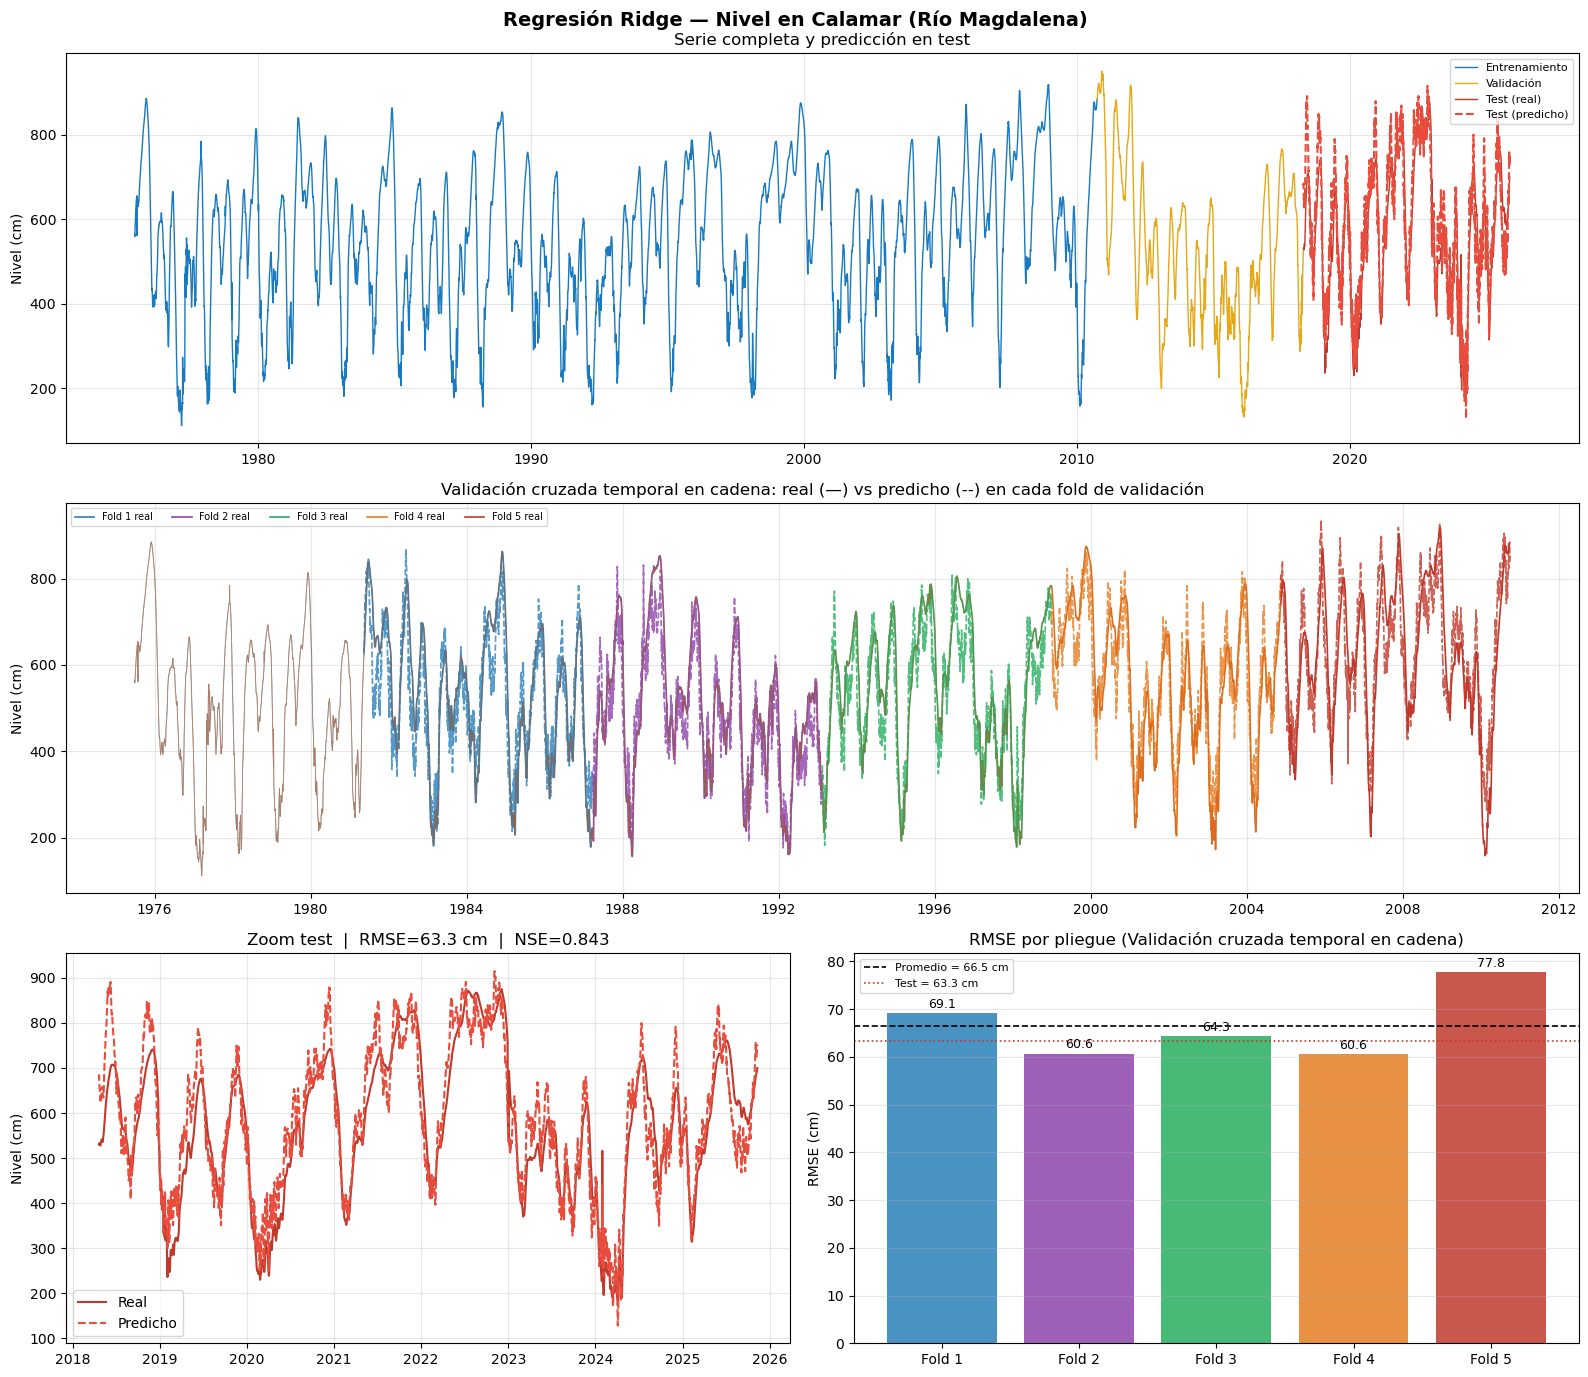

In [8]:
fig = plt.figure(figsize=(16, 14))
fig.suptitle("Regresión Ridge — Nivel en Calamar (Río Magdalena)", fontsize=14, fontweight="bold")

ax1 = fig.add_subplot(3, 2, (1, 2))
ax1.plot(f_train, y_train,     color="#1a7abf", lw=1,   label="Entrenamiento")
ax1.plot(f_val,   y_val,       color="#e6a817", lw=1,   label="Validación")
ax1.plot(f_test,  y_test,      color="#c0392b", lw=1,   label="Test (real)")
ax1.plot(f_test,  y_test_pred, color="#e74c3c", lw=1.5, ls="--", label="Test (predicho)")
ax1.set_title("Serie completa y predicción en test")
ax1.set_ylabel("Nivel (cm)")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(3, 2, (3, 4))
colores_fold = ["#2980b9", "#8e44ad", "#27ae60", "#e67e22", "#c0392b"]
for i, (ff_tr, yf_tr, ff_vl, yf_vl, yf_pr) in enumerate(fold_info):
    ax2.plot(ff_tr, yf_tr, color=colores_fold[i], lw=0.6, alpha=0.3)
    ax2.plot(ff_vl, yf_vl, color=colores_fold[i], lw=1.2, label=f"Fold {i+1} real")
    ax2.plot(ff_vl, yf_pr, color=colores_fold[i], lw=1.2, ls="--", alpha=0.8)
ax2.set_title("Validación cruzada temporal en cadena: real (—) vs predicho (--) en cada fold de validación")
ax2.set_ylabel("Nivel (cm)")
ax2.legend(fontsize=7, ncol=5)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(3, 2, 5)
ax3.plot(f_test, y_test,      color="#c0392b", lw=1.5, label="Real")
ax3.plot(f_test, y_test_pred, color="#e74c3c", lw=1.5, ls="--", label="Predicho")
ax3.set_title(f"Zoom test  |  RMSE={rmse_test:.1f} cm  |  NSE={nse_test:.3f}")
ax3.set_ylabel("Nivel (cm)")
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(3, 2, 6)
folds = [f"Fold {i+1}" for i in range(N_SPLITS)]
bars = ax4.bar(folds, cv_rmse, color=colores_fold, alpha=0.85)
ax4.axhline(np.mean(cv_rmse), color="black", lw=1.2, ls="--", label=f"Promedio = {np.mean(cv_rmse):.1f} cm")
ax4.axhline(rmse_test, color="#c0392b", lw=1.2, ls=":", label=f"Test = {rmse_test:.1f} cm")
for bar, val in zip(bars, cv_rmse):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.1f}", ha="center", va="bottom", fontsize=9)
ax4.set_title("RMSE por pliegue (Validación cruzada temporal en cadena)")
ax4.set_ylabel("RMSE (cm)")
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("ridge_magdalena_resultados.png", dpi=150)
plt.show()


## 8.8. Coeficientes del modelo

In [9]:

print("\nCoeficientes Ridge (modelo final)")
for feat, coef in zip(features, ridge_final.coef_):
    print(f"  {feat:<25} {coef:+.4f}")
print(f"  {'Intercepto':<25} {ridge_final.intercept_:+.4f}")


Coeficientes Ridge (modelo final)
  Achi                      +3.2302
  ElBanco                   +182.3577
  SaladoBlanco              -2.1890
  PuertoBerrio              -13.6731
  Barrancabermeja           -29.6322
  Intercepto                +536.0272


El modelo de regresión Ridge utiliza una división temporal coherente (train: 1975–2010, validación: 2010–2018 y test: 2018–2025) y validación cruzada en cadena, lo que garantiza un comportamiento realista en el tiempo. El hiperparámetro óptimo (alpha ≈ 19.3) indica una regularización adecuada que evita sobreajuste. En validación cruzada el modelo muestra un rendimiento sólido y estable (R² ≈ 0.83, MAE ≈ 53 cm), mientras que en test alcanza un desempeño aún mejor (R² ≈ 0.84, NSE ≈ 0.84), lo que confirma buena capacidad de generalización. Los coeficientes revelan que las estaciones de Achi y El Banco son las que más impacto tienen en Calamar, y esta última tiene la mayor influencia positiva, mientras que otras estaciones presentan relaciones inversas, posiblemente relacionado con dinámicas hidráulicas o desfases temporales no modelados.